## 1. Problem definition

## Definición

* En el presente laboratorio analizaremos y agruparemos paises en función de sus usuarios de Internet y sus suscripciones ordenadas por velocidad de banda ancha.

* El objetivo es identificar patrones y segmentar países en *clusters* que compartan características similares en cuanto a sus niveles de conectividad y adopción de internet.

* Este análisis puede ayudar a entender mejor la distribución de la conectividad a internet a nivel global y proporcionar *insights* que podrían ser útiles para políticas de desarrollo y estrategias de inversión en infraestructura de internet.

## Tipos de datos

A continuación se detallan los tipos de datos de las columnas de los archivos CSV con los que se trabajará:


1.   **Number of Internet users**

      *   Entidad
          *   Tipo: Categórico
          *   Descripción: Nombre del país.
          *   Ejemplo: "Niger", "Mauricio", "Chile".
      *   Año
          *   Tipo: Numérico
          *   Descripción: Año en el que se portan los datos.
          *   Ejemplo: 2010, 2011, 2012.
      *   Número de usuarios de Internet
          *   Tipo: Numérico
          *   Descripción: Cantidad total de usuarios de Internet en el país.
          *   Ejemplo: 10000000, 150000000.   

1.   **Landline Internet suscriptions by speed**

      *   Entidad
          *   Tipo: Categórico
          *   Descripción: Nombre del país.
          *   Ejemplo: "Niger", "Mauricio", "Chile".
      *   Año
          *   Tipo: Numérico
          *   Descripción: Año en el que se portan los datos.
          *   Ejemplo: 2010, 2011, 2012.
      *   Suscripciones a Internet fijo
          *   Tipo: Numérico
          *   Descripción: Número total de suscripciones a Internet de banda ancha fija con una velocidad de descarga de 10 Mbps o más.
          *   Ejemplo: 5000000, 2000000.

## 2. Data collection and pre-processing

Se declaran las bibliotecas necesarias para la ejecucion de las sentencias

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from scipy import stats
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

EN EL SIGUIENTE FRAGMENTO DE CODIGO SE REALIZA ESTAS ACTIVIDADES:

1. Se extraen la data de ambos archivos, almacenando en 2 Dataframes
* "*sub_speed*" ---> Landline intener subs. by speed
* "*numUser*" ---> number of internet users

2. Se eliminan las filas de ambas Dataframes dado las siguientes reglas:
* Entidades agrupados por ingresos
* Entidades representado como region
* Entidades cuyos paises tengan valores atipicos (Valores sumamente altos)
* Velocidad de internet iguales a 0
* Valores de cualquier columna cuyo contenido es NaN

3. Se combinan los 2 Dataframes ("*sub_speed*" y "*numUser*") en un solo Dataframe ("*numUser*"), donde debe coincidir las filas a partir de la entidad(*Entity*) y los años(*Year*). Esta ejecucion involucra eliminar las filas que falten informacion.

In [2]:
# Se extraen los datos de ambos archivos y se selecciona las columnas a utilizar
sub_speed = pd.read_csv("../data/landline-internet-subscriptions-by-speed.csv", sep = ",",  usecols = ["Entity", "Year", "10 Mbits/s and over"])
numUser = pd.read_csv("../data/number-of-internet-users.csv", low_memory = False, sep = ",", usecols = ["Entity", "Year", "Number of people using the Internet"])


# Lista que contiene entidades por categoria, region y paises con valores atipicos
delete = ['High-income countries', 'Low-income countries', 'Lower-middle-income countries' , 'Upper-middle-income countries',
          'World', 'Asia', 'Europe', 'North America', 'Oceania', 'South America', 'Africa', 'China', 'United States', 'India',
          'Indonesia', 'Nigeria', 'Russia', 'Brazil', 'Bangladesh'
          ]

# Eliminan las filas que contengan las entidades de la lista
numUser = numUser.drop(numUser[numUser['Entity'].isin(delete)].index)
sub_speed = sub_speed.drop(sub_speed[sub_speed['Entity'].isin(delete)].index)

# Combina las columnas de "sub_speed" y "numUser"
# Igualando en las entidades y años
numUser = numUser.merge(sub_speed, on=["Entity", "Year"])

# Eliminan las filas con valores iguales a 0 y "NaN"
numUser = numUser.drop(numUser[numUser["10 Mbits/s and over"] == 0].index)
numUser = numUser.dropna()

Selecciono los paises para realizar los algoritmos de cluster, Kmeans y DBSCAN. Se normaliza el numero de usuario de internet y la velocidad de intenet.

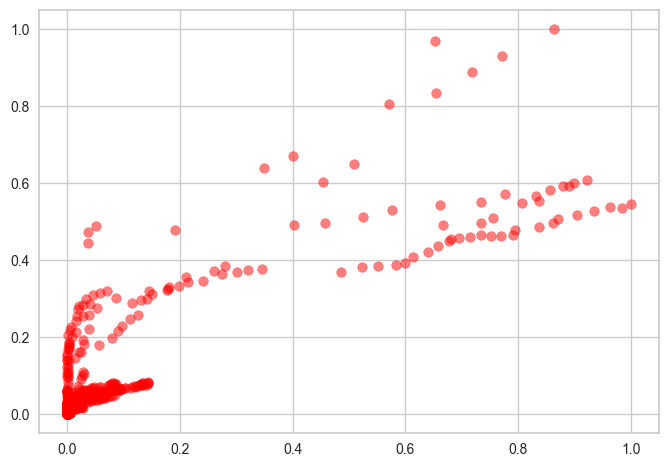

In [3]:
country = ['Sri Lanka',
'Mongolia',
'Greece',
'Palestine',
'Mexico',
'Colombia',
'Ghana',
'Oman',
'United Kingdom',
'British Virgin Islands',
'Algeria',
'Antigua and Barbuda',
'Peru',
'Bulgaria',
'France',
'Moldova',
'Slovenia',
'Monaco',
'Panama',
'Iceland',
'Switzerland',
'Jamaica',
'Austria',
'Israel',
'South Korea',
'Serbia',
'Hong Kong',
'Singapore',
'Madagascar',
'Burundi',
'Madagascar',
'El Salvador',
'Argentina',
'Eswatini',
'Angola',
'Bolivia',
'French Polynesia',
'Faroe Islands',
'Andorra',
'Afghanistan',
'Faroe Islands',
'Andorra',
'Bermuda',
'Morocco',
'Palestine',
'Tonga',
'Saint Vincent and the Grenadines',
'Panama',
'Niger',
'Bhutan']

numUser = numUser[numUser['Entity'].isin(country)]

# Obtengo x: Velocidad de descargar e y: numero de usuario en internet
x = numUser['10 Mbits/s and over']
y = numUser['Number of people using the Internet']

code = LabelEncoder()
numUser['Paises'] = code.fit_transform(numUser['Entity'])

z = numUser['Paises']
# Normaliza x e y en un rango entre 0 y 1

min_x = x.min()
min_y = y.min()

X = (x - x.min()) / (x.max() - x.min())
Y = (y - y.min()) / (y.max() - y.min())

# Se grafica la data

graph_point = plt.scatter(X, Y, marker = 'o', c = 'red', alpha = 0.5)
graph_point

X = X.to_numpy().reshape(-1, 1)

# XY almacena los valores de la velocidad de descargar y el numero de usuario en internet
XY = np.column_stack((X, Y))

data = np.column_stack((x, y, z))

## 3. Model Training

Una vez que los datos son procesados, se emplearan en los siguientes algoritmos de Unsupervised Clustering mediante la libreria SCI-KIT LEARN:

1. KMeans: Su objetivo es agrupar los datos buscando similitudes en cuanto al numero de personas en internet (eje X) y la velocidad de internet como (eje y). Luego de agrupar los datos se ubican los centroides en base al promedio de un grupo, en este caso se implementara 5 clusters. Para ello se dispone 3 estrategias para iniciar el KMeans, con la finalidad de realizar comparativas en los resultados.

* "k-means++": permite que los centroides esten distribuidos en la grafica lo mas disperso posible para representar de la mejor forma  las agrupaciones de datos.

* "random": los centroides se seleccionar al azar la ubicacion dichos centroides sin tomar en consideracion en como esta distribuido los datos.

* "minibatch":  los datos son divididos en pequeñas muestras y a partir de ello se realizan las iteraciones necesarias para actualizar las ubicaciones.

2. DBSCAN: agrupa los datos en funcion de densidad en el espacio, se trabajara en un entorno de 3 dimensiones [ entidades (representado en formato de numeros), numero de personas en internet y velocidad de internet ]. En este algoritmo se define la distancia maxima de un cluster y un numero minimo de puntos para considerar un cluster como tal. Para ello se tiene 2 loop para probar 3 diferentes valores en Epsilon y minino de puntos.

## 4. Model Evaluation

**4.1 - KMeans**

---

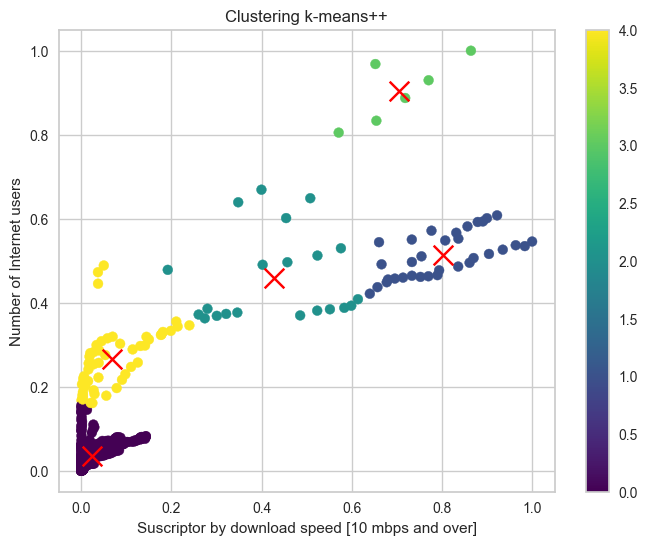

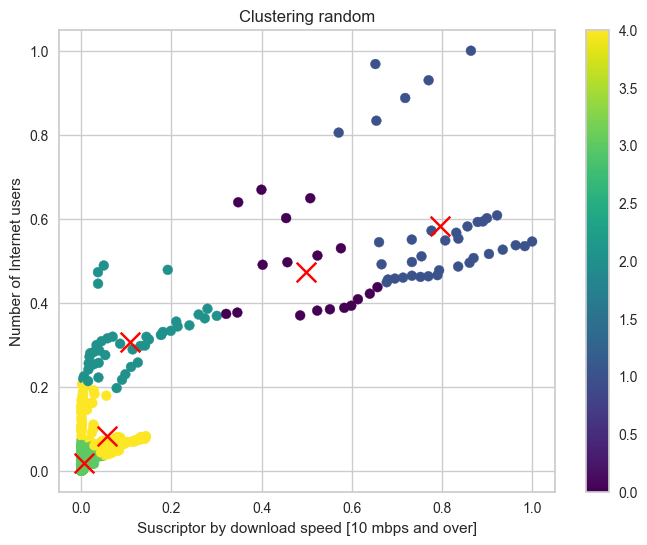

In [4]:
# Ejecuto Kmeans con diferentes estrategias de iniciacion
for modo in ['k-means++','random']:
  kmeans = KMeans(init=modo, n_clusters = 5, random_state=42)
  kmeans.fit(XY)
  labels = kmeans.labels_

  centroids = kmeans.cluster_centers_

  # Crear una figura y un eje
  plt.subplots(figsize=(8, 6))

  # Graficar los puntos de datos y los centroides
  plt.scatter(XY[:, 0], XY[:, 1], c=labels, s=50, cmap='viridis')
  plt.colorbar()
  plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, c='red')

  # Establecer etiquetas y título
  plt.xlabel('Suscriptor by download speed [10 mbps and over]')
  plt.ylabel('Number of Internet users')
  plt.title('Clustering ' + modo)

# Mostrar el gráfico
plt.show()


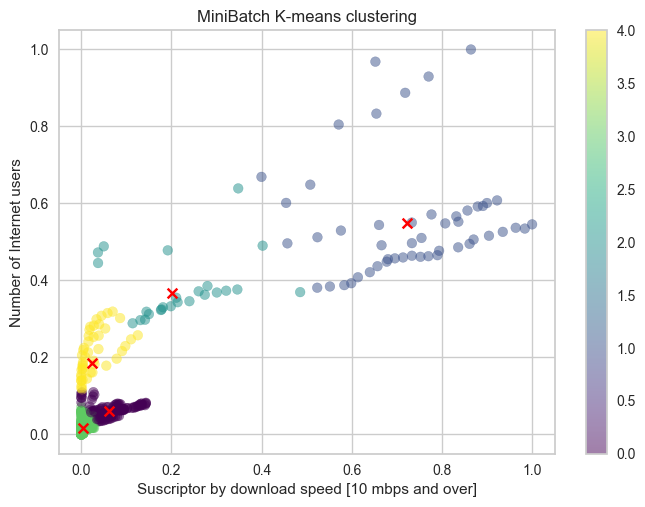

In [5]:
# Implementación de MiniBatch K-means
k = 5  # Número de clusters
batch_size = 10  # Tamaño de minibatch

kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, random_state=42)
kmeans.fit(XY)

# Predicciones y visualización de resultados
labels = kmeans.predict(XY)
centroids = kmeans.cluster_centers_

plt.scatter(XY[:, 0], XY[:, 1], c=labels, marker='o', alpha=0.5, cmap='viridis')
plt.colorbar()
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')
plt.xlabel('Suscriptor by download speed [10 mbps and over]')
plt.ylabel('Number of Internet users')
plt.title('MiniBatch K-means clustering')
plt.show()

**4.2 - DBSCAN**

---

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

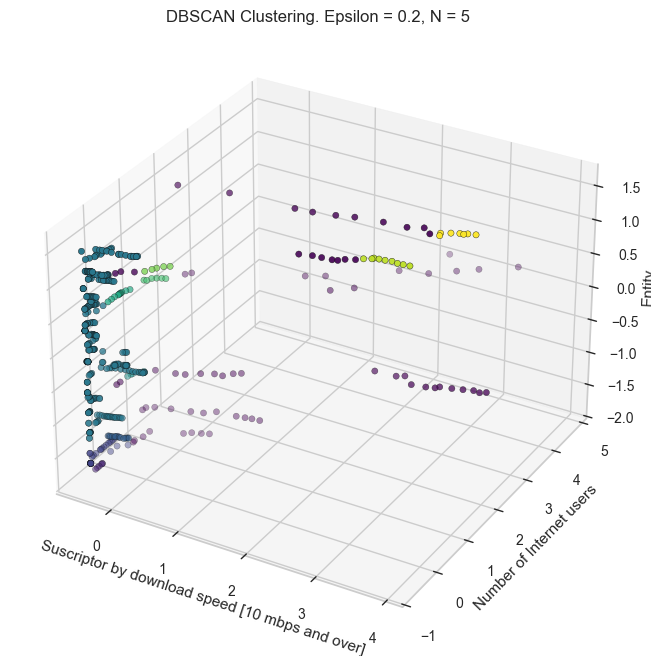

In [6]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

for i in [0.2, 0.7, 1.2]:
  for j in [5, 10, 15]:

      # Aplicar DBSCAN
      dbscan = DBSCAN(eps=i, min_samples=j)
      clusters = dbscan.fit_predict(data_scaled)

      fig = plt.figure(figsize = (12,8))
      ax = fig.add_subplot(111, projection='3d')

      # Graficar los puntos en 3D con colores de acuerdo a los clusters
      ax.scatter(data_scaled[:, 0], data_scaled[:, 1], data_scaled[:, 2], c=clusters, cmap='viridis', marker='o', edgecolor='k')

      # Configurar etiquetas y título
      ax.set_xlabel('Suscriptor by download speed [10 mbps and over]')
      ax.set_ylabel('Number of Internet users')
      ax.set_zlabel('Entity')
      ax.set_title('DBSCAN Clustering. Epsilon = ' + str(i) + ', N = ' + str(j))


      norm = Normalize(vmin=clusters.min(), vmax=clusters.max())
      sm = ScalarMappable(cmap='viridis', norm=norm)
      sm.set_array([])

      # Agregar el colorbar a la figura
      cbar = plt.colorbar(sm)
      cbar.set_label('Cluster')

plt.show()

## 5. Deployment and Monitoring

Requisitos a tomar en consideración

En este proyecto, se debe tener en cuenta la eliminación de países que distorsionaban la gráfica debido a una gran diferencia entre el promedio general de los países trabajados. Esto se debió a que los datos eran ya sea muy grandes, muy pequeños, o incluso se encontraan países con secciones de la tabla sin datos. Por ejemplo, China e India, cuyos números de personas que utilizan internet se encontraban significativamente por encima del promedio general, fueron algunos de los países eliminados del proyecto.

En tanto a la seccion de k-means, es importante apreciar que se utiliza "k-means++" para dispersar los centroides, "random" para seleccionar centroides al azar, y "minibatch" para dividir los datos en pequeñas muestras. Se puede intrepretar que para las 3 estrategias muestran diferentes agrupacion de datos dado que utilizando diferentes procesos y formas de distribuir los datos. Esto depende los datos que se encuentra disperso de la mayoria, el numero de clusters a implementar y/o en como distribuir los datos si las agrupaciones son cercanas entre si.  

Por parte del DBSCAN, utilizando diferentes valores para los parametros Epsilon y el minimo de puntos, en cada grafico se puede visualizar la total de clusters junto con su agrupacion de datos. A medida que 1 de los 2 parametros aumente su valor, mas grande es la agrupacion. Con respecto a los paises que fueron eliminados durante el procesamiento de datos altera en como agrupa los datos. Debido que si existen valores sumamente altos, aumenta la concentracion de los datos bajos.
